## Statistical method

### Load and inspect the dataset


In [3]:
import pandas as pd

# Data preprocessing is completed in 01_data_preprocessing.ipynb
# Directly load its output file
df = pd.read_csv('../data/processed/01_preprocessed.csv')

print("✅ Loaded preprocessed data: ../data/processed/01_preprocessed.csv")
print("Dataset Shape:", df.shape)
print(df.head())

✅ Loaded preprocessed data: ../data/processed/01_preprocessed.csv
Dataset Shape: (10345, 41)
  employment_type product_category  bnpl_installments  missed_payments  \
0        Salaried      Electronics                 12                1   
1         Student          Fashion                 12                1   
2   Self-Employed      Electronics                  3                2   
3        Salaried           Sports                  6                5   
4        Salaried      Electronics                  9                0   

   default_flag   location  risk_score  customer_segment  \
0             0  Australia   -0.493560                 1   
1             0        USA    0.998931                 2   
2             0  Australia    0.459976                 2   
3             1    Germany    2.331512                 2   
4             0      India   -0.937753                 2   

   transaction_year_onehot  transaction_month  ...  \
0                        1                  6  

### Data Loading & Variable Setup
In this step, we will load your preprocessed dataset and organize the features into the categories we identified earlier (Categorical, Ordinal, and Ratio).

In [4]:
import pandas as pd
import numpy as np
from scipy import stats

# Load the preprocessed data 
df = pd.read_csv('../data/processed/01_preprocessed.csv') 

raw_data_types = {
    'Categorical': ['employment_type', 'product_category', 'location', 'default_flag'],
    'Ordinal': ['customer_segment'],
    'Interval': ['credit_score', 'transaction_date'],
    'Ratio': ['age', 'monthly_income', 'purchase_amount', 'bnpl_installments', 
              'repayment_delay_days', 'missed_payments', 'app_usage_frequency', 
              'debt_to_income_ratio', 'risk_score']  
}

#以下 'bnpl_installments', 'missed_payments' 在 ordinal 代表在 statical method 中要視其為 ordinal type
preprocessed_data_types = {
    'Chi-Square': [
        'employment_type', 
        'product_category', 
        'location'
    ],
    
    'Fisher': [
        'transaction_year_onehot',
        'transaction_is_weekend'
    ],
    
    'Ordinal': [
        'customer_segment', 
        'transaction_month', 
        'transaction_day', 
        'transaction_dayofweek',
        'bnpl_installments', 
        'missed_payments'
    ],
    
    'Mann-Whitney-Same': [
        'app_usage_frequency_log1p'
    ],
    
    'Mann-Whitney-Diff': [
        'credit_score_log1p',
        'age_log1p', 
        'monthly_income_log1p', 
        'purchase_amount_log1p', 
        'repayment_delay_days_log1p', 
        'debt_to_income_ratio_log1p'
    ],
    
    'T-Test-Diff': [
        'risk_score'
    ],
    
    'target': [
        'default_flag'
    ]
}

target = preprocessed_data_types['target'][0]

categorical_vars = (
    preprocessed_data_types['Chi-Square']
    + preprocessed_data_types['Fisher']
)

# Quick Data Quality Check
print("Dataset Shape:", df.shape)
print("\nTarget Distribution (default_flag):")
print(df[target].value_counts(normalize=True))

# Display the first few rows of the grouped columns to verify
print("\nSample Data (Categorical & Target):")
print(df[[target] + categorical_vars].head())

Dataset Shape: (10345, 41)

Target Distribution (default_flag):
default_flag
0    0.609473
1    0.390527
Name: proportion, dtype: float64

Sample Data (Categorical & Target):
   default_flag employment_type product_category   location  \
0             0        Salaried      Electronics  Australia   
1             0         Student          Fashion        USA   
2             0   Self-Employed      Electronics  Australia   
3             1        Salaried           Sports    Germany   
4             0        Salaried      Electronics      India   

   transaction_year_onehot  transaction_is_weekend  
0                        1                       1  
1                        0                       0  
2                        1                       0  
3                        1                       1  
4                        0                       1  


In [5]:
# =========================
# Value counts for Chi-Square, Fisher, and Ordinal variables
# =========================

check_groups = ['Chi-Square', 'Fisher', 'Ordinal']

for group_name in check_groups:
    print(f"\n\n==============================")
    print(f"{group_name} Variables")
    print(f"==============================")
    
    for col in preprocessed_data_types[group_name]:
        print(f"\n--- {col} ---")
        print(df[col].value_counts(dropna=False).sort_index())



Chi-Square Variables

--- employment_type ---
employment_type
Salaried         2632
Self-Employed    2550
Student          2531
Unemployed       2632
Name: count, dtype: int64

--- product_category ---
product_category
Beauty         2072
Electronics    2085
Fashion        2166
Home           2052
Sports         1970
Name: count, dtype: int64

--- location ---
location
Australia    1722
Canada       1740
Germany      1760
India        1723
UK           1664
USA          1736
Name: count, dtype: int64


Fisher Variables

--- transaction_year_onehot ---
transaction_year_onehot
0    5200
1    5145
Name: count, dtype: int64

--- transaction_is_weekend ---
transaction_is_weekend
0    7413
1    2932
Name: count, dtype: int64


Ordinal Variables

--- customer_segment ---
customer_segment
0     576
1    2200
2    7569
Name: count, dtype: int64

--- transaction_month ---
transaction_month
1     899
2     823
3     895
4     858
5     808
6     862
7     874
8     868
9     876
10    853
11   

### Categorical Feature Analysis (Chi-Square & Fisher's Exact Tests)

In [6]:
from scipy.stats import chi2_contingency

chi_square_vars = preprocessed_data_types['Chi-Square']

chi_square_results = []

for col in chi_square_vars:
    print(f"\n==============================")
    print(f"Chi-Square Test: {col} vs {target}")
    print(f"==============================")
    
    # Create contingency table
    contingency_table = pd.crosstab(df[col], df[target])
    
    print("\nContingency Table:")
    display(contingency_table)
    
    # Run chi-square test of independence
    chi2_stat, p_value, dof, expected = chi2_contingency(contingency_table)
    
    # Convert expected counts to DataFrame
    expected_df = pd.DataFrame(
        expected,
        index=contingency_table.index,
        columns=contingency_table.columns
    )
    
    print("\nExpected Frequencies:")
    display(expected_df.round(2))
    
    # Check minimum expected frequency
    min_expected = expected_df.min().min()
    
    # Store result
    chi_square_results.append({
        'variable': col,
        'chi2_statistic': chi2_stat,
        'p_value': p_value,
        'degrees_of_freedom': dof,
        'min_expected_frequency': min_expected,
        'significant_at_0.05': p_value < 0.05
    })

# Create summary table
chi_square_results_df = pd.DataFrame(chi_square_results)

print("\n\n==============================")
print("Chi-Square Test Summary (3+ categories)")
print("==============================")

display(
    chi_square_results_df.sort_values('p_value').round(6)
)


Chi-Square Test: employment_type vs default_flag

Contingency Table:


default_flag,0,1
employment_type,,
Salaried,1771,861
Self-Employed,1881,669
Student,1302,1229
Unemployed,1351,1281



Expected Frequencies:


default_flag,0,1
employment_type,,
Salaried,1604.13,1027.87
Self-Employed,1554.16,995.84
Student,1542.58,988.42
Unemployed,1604.13,1027.87



Chi-Square Test: product_category vs default_flag

Contingency Table:


...

default_flag,0,1
location,,
Australia,1052,670
Canada,1065,675
Germany,1051,709
India,1067,656
UK,1006,658
USA,1064,672



Expected Frequencies:


default_flag,0,1
location,,
Australia,1049.51,672.49
Canada,1060.48,679.52
Germany,1072.67,687.33
India,1050.12,672.88
UK,1014.16,649.84
USA,1058.05,677.95




Chi-Square Test Summary (3+ categories)


,variable,chi2_statistic,p_value,degrees_of_freedom,min_expected_frequency,significant_at_0.05
0,employment_type,418.814775,0.000000,3,988.423393,True
1,product_category,6.444930,0.168293,4,769.337844,False
2,location,2.134299,0.830267,5,649.836636,False


In [7]:
from scipy.stats import fisher_exact

fisher_vars = preprocessed_data_types['Fisher']

fisher_results = []

for col in fisher_vars:
    print(f"\n==============================")
    print(f"Fisher's Exact Test: {col} vs {target}")
    print(f"==============================")
    
    # Create contingency table
    contingency_table = pd.crosstab(df[col], df[target])
    
    print("\nContingency Table:")
    display(contingency_table)
    
    if contingency_table.shape != (2, 2):
        raise ValueError(
            f"Fisher's exact test requires 2x2 table, got {contingency_table.shape} for {col}."
        )
    
    odds_ratio, p_value = fisher_exact(contingency_table.values)
    
    fisher_results.append({
        'variable': col,
        'odds_ratio': odds_ratio,
        'p_value': p_value,
        'significant_at_0.05': p_value < 0.05
    })

# Create summary table
fisher_results_df = pd.DataFrame(fisher_results)

print("\n\n==============================")
print("Fisher's Exact Test Summary (2 categories)")
print("==============================")

display(
    fisher_results_df.sort_values('p_value').round(6)
)


Fisher's Exact Test: transaction_year_onehot vs default_flag

Contingency Table:


default_flag,0,1
transaction_year_onehot,,
0,3193,2007
1,3112,2033



Fisher's Exact Test: transaction_is_weekend vs default_flag

Contingency Table:


default_flag,0,1
transaction_is_weekend,,
0,4508,2905
1,1797,1135




Fisher's Exact Test Summary (2 categories)


,variable,odds_ratio,p_value,significant_at_0.05
0,transaction_year_onehot,1.039320,0.34357,False
1,transaction_is_weekend,0.980134,0.67097,False


### Add Cramér’s V effect size

In [8]:

def cramers_v(contingency_table):
    chi2_stat, _, _, _ = chi2_contingency(contingency_table)
    n = contingency_table.sum().sum()
    r, k = contingency_table.shape
    
    return np.sqrt(chi2_stat / (n * (min(r, k) - 1)))

chi_square_vars = preprocessed_data_types['Chi-Square']
fisher_vars = preprocessed_data_types['Fisher']

cramers_v_results = []

for col in chi_square_vars + fisher_vars:
    contingency_table = pd.crosstab(df[col], df[target])
    v = cramers_v(contingency_table)
    
    cramers_v_results.append({
        'variable': col,
        'cramers_v': v
    })

cramers_v_df = pd.DataFrame(cramers_v_results)

chi_square_results_df = chi_square_results_df.merge(
    cramers_v_df,
    on='variable',
    how='left'
)

fisher_results_df = fisher_results_df.merge(
    cramers_v_df,
    on='variable',
    how='left'
)

print("\n\n==============================")
print("Chi-Square Test Summary (3+ categories) with Cramer's V")
print("==============================")

display(
    chi_square_results_df.sort_values('p_value').round(6)
)

print("\n\n==============================")
print("Fisher's Exact Test Summary (2 categories) with Cramer's V")
print("==============================")

display(
    fisher_results_df.sort_values('p_value').round(6)
)



Chi-Square Test Summary (3+ categories) with Cramer's V


,variable,chi2_statistic,p_value,degrees_of_freedom,min_expected_frequency,significant_at_0.05,cramers_v
0,employment_type,418.814775,0.000000,3,988.423393,True,0.201208
1,product_category,6.444930,0.168293,4,769.337844,False,0.024960
2,location,2.134299,0.830267,5,649.836636,False,0.014364




Fisher's Exact Test Summary (2 categories) with Cramer's V


,variable,odds_ratio,p_value,significant_at_0.05,cramers_v
0,transaction_year_onehot,1.039320,0.34357,False,0.009209
1,transaction_is_weekend,0.980134,0.67097,False,0.004188


#### 卡方獨立性檢定結果

本節使用 Chi-Square independence test 檢驗多類別變數與 `default_flag` 之間是否存在統計關聯；二元變數（`transaction_year_onehot`、`transaction_is_weekend`）改用 Fisher's exact test。

結果顯示，只有 `employment_type` 與 `default_flag` 之間達到統計顯著水準（p < 0.05）。其 Cramér’s V 約為 0.20，表示兩者之間具有小到中等程度的關聯。從列聯表觀察可知，Student 與 Unemployed 的違約比例明顯高於 Salaried 與 Self-Employed，因此就業類型可能是影響違約風險的重要類別特徵。

相較之下，`product_category`、`location`（Chi-Square）以及 `transaction_year_onehot`、`transaction_is_weekend`（Fisher）的檢定結果皆未達顯著水準，且 Cramér’s V 接近 0，表示這些變數與 `default_flag` 之間沒有明顯關聯。

## Distribution plots for Ordinal variables

為確保 code 的整體性，這裡再畫一次類別在 default_flag = 0,1 下的分布圖

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

ordinal_vars = preprocessed_data_types['Ordinal']

for col in ordinal_vars:
    print(f"\n==============================")
    print(f"Percentage Distribution of {col} by {target}")
    print(f"==============================")
    
    percentage_table = pd.crosstab(
        df[col],
        df[target],
        normalize='columns'
    ) * 100
    
    display(percentage_table.round(2))


Percentage Distribution of customer_segment by default_flag


default_flag,0,1
customer_segment,,
0,8.58,0.87
1,30.86,6.29
2,60.56,92.85



Percentage Distribution of transaction_month by default_flag


default_flag,0,1
transaction_month,,
1,8.49,9.01
2,8.03,7.85
3,8.30,9.21
4,8.63,7.77
5,7.61,8.12
6,8.31,8.37
7,8.68,8.09
8,8.37,8.42
9,8.71,8.09



Percentage Distribution of transaction_day by default_flag


...

default_flag,0,1
transaction_dayofweek,,
0,14.45,14.11
1,14.07,15.52
2,14.04,14.28
3,14.42,14.03
4,14.53,13.96
5,13.77,13.42
6,14.73,14.68



Percentage Distribution of bnpl_installments by default_flag


default_flag,0,1
bnpl_installments,,
3,25.63,25.52
6,24.95,23.32
9,25.06,25.84
12,24.36,25.32



Percentage Distribution of missed_payments by default_flag


default_flag,0,1
missed_payments,,
0,42.46,25.42
1,37.99,35.69
2,17.32,21.71
3,1.82,13.32
4,0.29,3.09
5,0.13,0.57
6,0.00,0.17
7,0.00,0.02


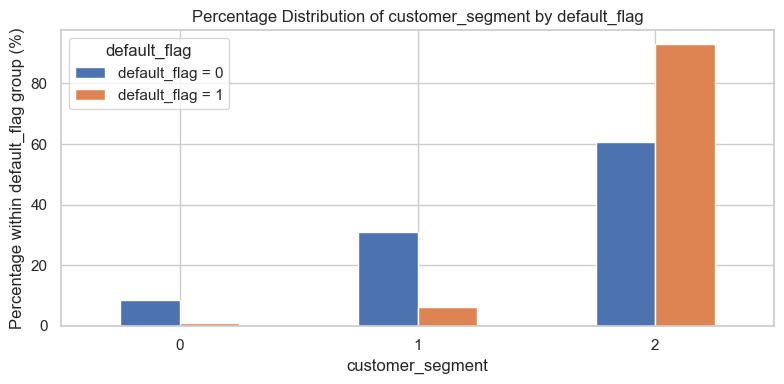

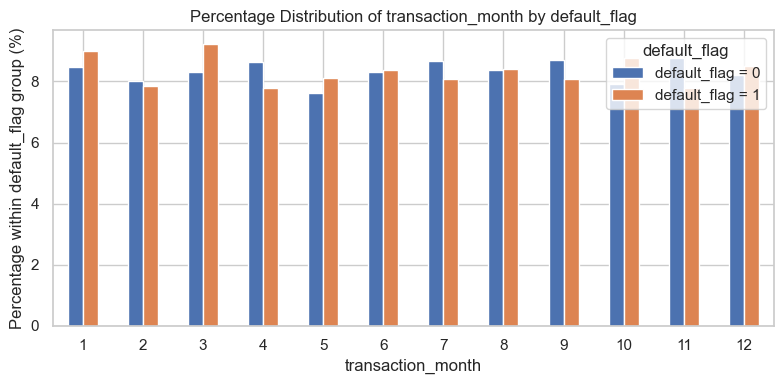

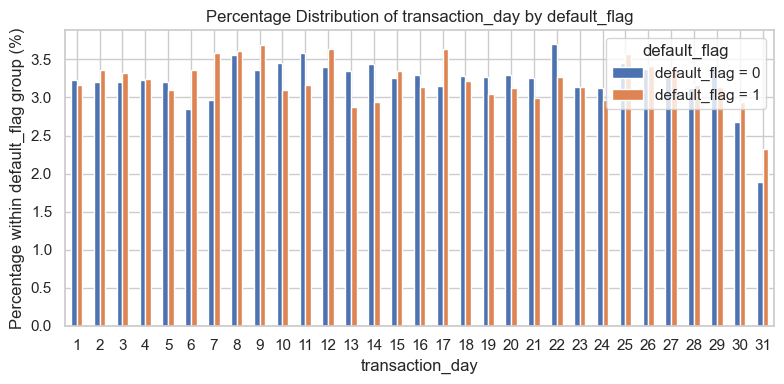

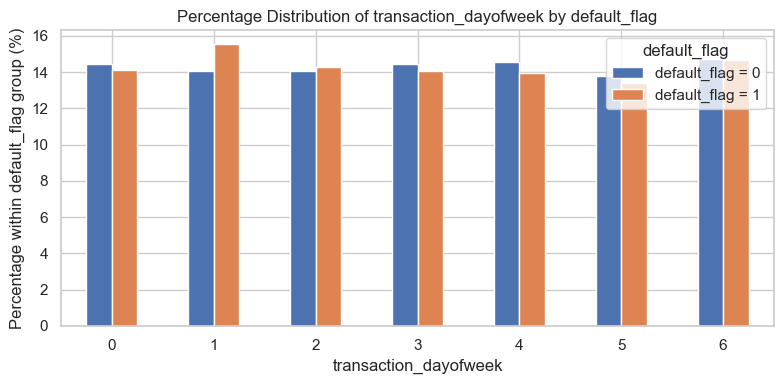

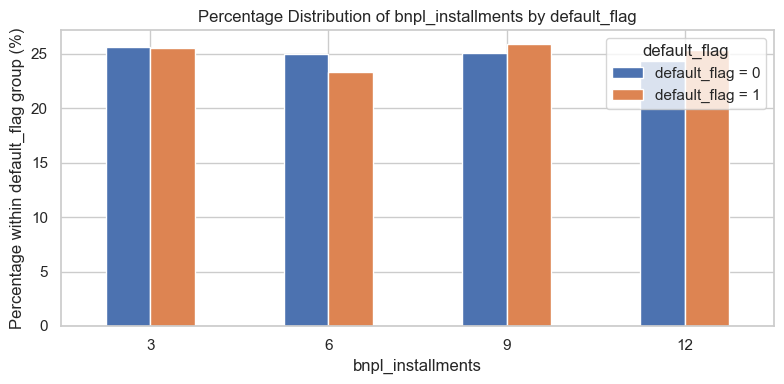

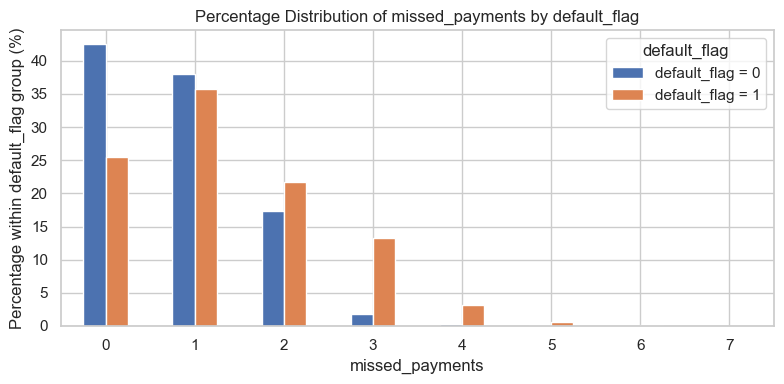

In [10]:
import matplotlib.pyplot as plt

for col in ordinal_vars:
    percentage_table = pd.crosstab(
        df[col],
        df[target],
        normalize='columns'
    ) * 100
    
    ax = percentage_table.plot(
        kind='bar',
        figsize=(8, 4)
    )
    
    plt.title(f"Percentage Distribution of {col} by {target}")
    plt.xlabel(col)
    plt.ylabel('Percentage within default_flag group (%)')
    plt.legend(title=target, labels=['default_flag = 0', 'default_flag = 1'])
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

result:

| Variable                | Distribution Difference | Interpretation           |
| ----------------------- | ----------------------- | ------------------------ |
| `customer_segment`      | Very different          | 違約組高度集中在 segment 2       |
| `transaction_month`     | Similar                 | 兩組月份分布接近                 |
| `transaction_day`       | Similar                 | 兩組日期分布接近                 |
| `transaction_dayofweek` | Similar                 | 兩組星期分布接近                 |
| `bnpl_installments`     | Similar                 | 兩組分期數分布接近                |
| `missed_payments`       | Very different          | 違約組 missed payments 明顯較高 |


## Mann-Whitney U Tests

這裡會用到前面畫圖的分析結果。

In [ ]:
from scipy.stats import mannwhitneyu

mann_whitney_same_shape_vars = [
    # From original instruction
    'app_usage_frequency_log1p',
    
    # From distributions look roughly similar
    'transaction_month',
    'transaction_day',
    'transaction_dayofweek',
    'bnpl_installments'
]

mann_whitney_diff_shape_vars = [
    # From original instruction
    'credit_score_log1p',
    'age_log1p',
    'monthly_income_log1p',
    'purchase_amount_log1p',
    'repayment_delay_days_log1p',
    'debt_to_income_ratio_log1p',
    
    # From distributions look clearly different
    'customer_segment',
    'missed_payments'
]


# Mann-Whitney U Tests


mann_whitney_results = []

def run_mann_whitney_test(df, variable, target, interpretation_type):
    """
    Run Mann-Whitney U test between default_flag = 0 and default_flag = 1.
    """
    
    group0 = df[df[target] == 0][variable].dropna()
    group1 = df[df[target] == 1][variable].dropna()
    
    u_stat, p_value = mannwhitneyu(
        group0,
        group1,
        alternative='two-sided'
    )
    
    result = {
        'variable': variable,
        'interpretation_type': interpretation_type,
        'group0_n': len(group0),
        'group1_n': len(group1),
        'group0_median': group0.median(),
        'group1_median': group1.median(),
        'group0_mean': group0.mean(),
        'group1_mean': group1.mean(),
        'u_statistic': u_stat,
        'p_value': p_value,
        'significant_at_0.05': p_value < 0.05
    }
    
    return result


# Run same-shape interpretation variables
for col in mann_whitney_same_shape_vars:
    mann_whitney_results.append(
        run_mann_whitney_test(
            df=df,
            variable=col,
            target=target,
            interpretation_type='same_shape_or_similar_distribution'
        )
    )

# Run different-shape interpretation variables
for col in mann_whitney_diff_shape_vars:
    mann_whitney_results.append(
        run_mann_whitney_test(
            df=df,
            variable=col,
            target=target,
            interpretation_type='different_shape_or_distribution'
        )
    )

mann_whitney_results_df = pd.DataFrame(mann_whitney_results)

display(
    mann_whitney_results_df.sort_values('p_value').round(6)
)

#### Add effect size: rank-biserial correlation

In [ ]:
def rank_biserial_correlation(u_stat, n1, n2):
    """
    Rank-biserial correlation for Mann-Whitney U.
    Range: -1 to 1.
    Larger absolute value means stronger group difference.
    """
    return (2 * u_stat) / (n1 * n2) - 1


mann_whitney_results_df['rank_biserial_corr'] = mann_whitney_results_df.apply(
    lambda row: rank_biserial_correlation(
        row['u_statistic'],
        row['group0_n'],
        row['group1_n']
    ),
    axis=1
)

display(
    mann_whitney_results_df.sort_values('p_value').round(6)
)

### Mann-Whitney U 檢定結果

本節使用 Mann-Whitney U test 比較 `default_flag = 0` 與 `default_flag = 1` 兩組在 ordinal 與非正態連續變數上的分布差異。

結果顯示，`customer_segment`、`credit_score_log1p`、`repayment_delay_days_log1p`、`missed_payments`、`monthly_income_log1p`、`debt_to_income_ratio_log1p`、`purchase_amount_log1p` 與 `age_log1p` 在兩組之間皆達統計顯著差異。

其中，`credit_score_log1p` 與 `monthly_income_log1p` 在非違約組中較高，表示信用分數與收入較高的客戶違約風險較低。相反地，`repayment_delay_days_log1p`、`missed_payments` 與 `debt_to_income_ratio_log1p` 在違約組中較高，表示還款延遲、錯過付款次數與債務收入比越高，違約風險可能越高。

`customer_segment` 與 `missed_payments` 雖然兩組中位數相同，但其分布形狀明顯不同，因此應解釋為兩組整體分布具有顯著差異，而非單純中位數不同。

另一方面，`bnpl_installments`、`transaction_month`、`transaction_day`、`transaction_dayofweek` 與 `app_usage_frequency_log1p` 未達顯著水準，表示這些變數在違約組與非違約組之間沒有明顯分布差異。

### Welch’s t-test for risk_score

In [ ]:
from scipy.stats import ttest_ind

# =========================
# Welch's t-test for risk_score
# =========================

t_test_var = preprocessed_data_types['T-Test-Diff'][0]

group0 = df[df[target] == 0][t_test_var].dropna()
group1 = df[df[target] == 1][t_test_var].dropna()

t_stat, p_value = ttest_ind(
    group0,
    group1,
    equal_var=False
)

t_test_result = pd.DataFrame([{
    'variable': t_test_var,
    'group0_n': len(group0),
    'group1_n': len(group1),
    'group0_mean': group0.mean(),
    'group1_mean': group1.mean(),
    'group0_median': group0.median(),
    'group1_median': group1.median(),
    'group0_std': group0.std(),
    'group1_std': group1.std(),
    't_statistic': t_stat,
    'p_value': p_value,
    'significant_at_0.05': p_value < 0.05
}])


# =========================
# Cohen's d effect size
# =========================

def cohens_d(group0, group1):
    n0 = len(group0)
    n1 = len(group1)
    
    s0 = group0.std()
    s1 = group1.std()
    
    pooled_std = np.sqrt(
        ((n0 - 1) * s0**2 + (n1 - 1) * s1**2) / (n0 + n1 - 2)
    )
    
    return (group0.mean() - group1.mean()) / pooled_std

d = cohens_d(group0, group1)

t_test_result['cohens_d'] = d

display(t_test_result.round(6))

#### risk_score 的 Welch’s t-test 結果

本節使用 Welch’s t-test 比較 `default_flag = 0` 與 `default_flag = 1` 兩組在 `risk_score` 平均數上的差異。由於此檢定不假設兩組變異數相等，因此符合原先指定的「t-test 異分布」設定。

檢定結果顯示，兩組的 `risk_score` 平均數存在顯著差異（p < 0.05）。非違約組的平均 `risk_score` 為 -0.3197，而違約組的平均 `risk_score` 為 0.4989，表示違約客戶的風險分數明顯較高。

Cohen’s d 約為 -0.893。負號是由於計算順序為 `default_flag = 0` 減去 `default_flag = 1`，代表非違約組的平均值低於違約組。若只看效果量大小，|d| 約為 0.893，屬於大的效果量，表示 `risk_score` 對區分違約與非違約具有相當明顯的實質差異。

### Correlation Analysis (Spearman Rank)

In [ ]:
# =========================
# Step 7: Spearman Correlation Analysis
# =========================

spearman_vars = (
    preprocessed_data_types['Ordinal']
    + preprocessed_data_types['Mann-Whitney-Same']
    + preprocessed_data_types['Mann-Whitney-Diff']
    + preprocessed_data_types['T-Test-Diff']
)

# Compute Spearman correlation matrix
spearman_corr_matrix = df[spearman_vars].corr(method='spearman')

display(spearman_corr_matrix.round(3))

#### Filter correlation pairs where absolute correlation > 0.75

In [ ]:
# Extract high Spearman correlations


high_corr_pairs = []

for i in range(len(spearman_corr_matrix.columns)):
    for j in range(i + 1, len(spearman_corr_matrix.columns)):
        var1 = spearman_corr_matrix.columns[i]
        var2 = spearman_corr_matrix.columns[j]
        corr_value = spearman_corr_matrix.iloc[i, j]
        
        if abs(corr_value) > 0.75:
            high_corr_pairs.append({
                'variable_1': var1,
                'variable_2': var2,
                'spearman_rho': corr_value,
                'abs_spearman_rho': abs(corr_value)
            })

high_corr_pairs_df = pd.DataFrame(high_corr_pairs)

if high_corr_pairs_df.empty:
    print("No variable pairs with |Spearman correlation| > 0.75 were found.")
else:
    high_corr_pairs_df = high_corr_pairs_df.sort_values(
        'abs_spearman_rho',
        ascending=False
    )
    
    display(high_corr_pairs_df.round(4))

#### visulization

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 10))

sns.heatmap(
    spearman_corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5
)

plt.title("Spearman Correlation Matrix")
plt.tight_layout()
plt.show()

## Spearman 相關分析結果

本節將 ordinal、interval 與 ratio 類型變數混合進行 Spearman correlation 分析，並篩選出絕對相關係數大於 0.75 的變數組合。

結果共發現四組高度相關變數：

1. `credit_score_log1p` 與 `monthly_income_log1p` 呈現非常強的正相關。
2. `credit_score_log1p` 與 `risk_score` 呈現非常強的負相關。
3. `missed_payments` 與 `repayment_delay_days_log1p` 呈現強正相關。
4. `monthly_income_log1p` 與 `debt_to_income_ratio_log1p` 呈現強負相關。

這些結果表示部分變數之間可能存在資訊重疊。例如，`risk_score` 與信用分數、收入、還款延遲等風險相關變數具有較強關聯，可能代表它整合了多項風險資訊。若後續要建立模型，應注意多重共線性或特徵冗餘問題。